In [28]:
import numpy as np
from PIL import Image
from IPython.display import display

In [38]:
from __future__ import annotations

NUM_ROWS = 28
NUM_COLS = 28
NUM_LABELS = 10

class Data:
  def __init__(self, pixels: list[list[int]], label: int):
    self.pixels = pixels
    self.flattened_pixels: list[int] = []
    for row in self.pixels:
      assert len(row) == NUM_ROWS
      self.flattened_pixels.extend(row)
    
    self.label = label
  
  @classmethod
  def from_csv_row(cls, csv: list[int]) -> Data:
    label = csv[0]
    pixels: list[list[int]] = []
    for row in range(NUM_ROWS):
      start_index = 1 + row * NUM_ROWS
      pixels.append(csv[start_index : start_index + NUM_COLS])

    return cls(pixels, label)
  
  def to_image(self) -> Image:
    pixel_array = np.array(self.pixels, dtype=np.uint8)
    return Image.fromarray(pixel_array, mode='L')
  
  def label_to_one_hot(self) -> list[int]:
    result = [0] * NUM_LABELS
    result[self.label] = 1
    return result

In [39]:
lines: list[str] = []
datas: list[Data] = []

with open('data/MNIST_CSV/mnist_train.csv') as f:
  lines = f.readlines()

for line in lines:
  datas.append(Data.from_csv_row([int(num) for num in line.split(',')]))

In [40]:
print(datas[0].label)
print(datas[0].label_to_one_hot())
display(datas[0].to_image())

5
[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]


In [41]:
distinct_labels = set()
for data in datas:
  distinct_labels.add(data.label)

In [42]:
distinct_labels

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [ ]:
from src.deep_learning.layer import get_random_layer
from src.deep_learning.multi_layer_perceptron import MultiLayerPerceptron
from src.deep_learning.op import TANH
from src.deep_learning.value import Value

multi_layer_perceptron = MultiLayerPerceptron(
    layers=[
        get_random_layer(NUM_ROWS, NUM_ROWS*NUM_COLS, TANH),
        get_random_layer(16, NUM_ROWS, TANH),
        get_random_layer(16, 16, TANH),
        get_random_layer(NUM_LABELS, 16),
    ],
)

In [44]:
data_index = 0

In [ ]:
from src.deep_learning.util import softmax

In [ ]:
for i in range(100):
  # compute loss
  predicted_output = multi_layer_perceptron.forward(datas[data_index].flattened_pixels)
  softmax_output = softmax(predicted_output)

  # update state
  data_index = data_index + 1 if data_index < len(datas) - 1 else 0


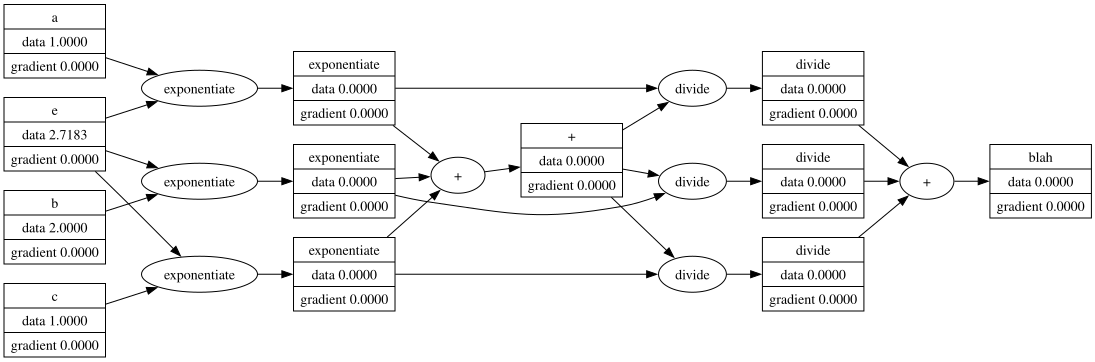

In [ ]:
from src.deep_learning.util import draw
from src.deep_learning.util import softmax
from src.deep_learning.value import Value
from src.deep_learning.op import PLUS

inputs = [
    Value(1.0, label='a'),
    Value(2.0, label='b'),
    Value(1.0, label='c'),
]
outputs = softmax(inputs)
root = Value(
    label='blah',
    op=PLUS,
    children=outputs,
)
draw(root)

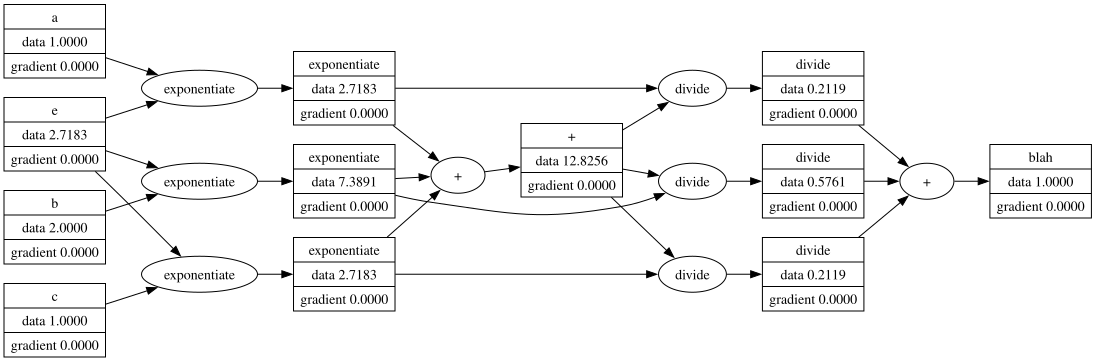

In [5]:
root.forward()
draw(root)

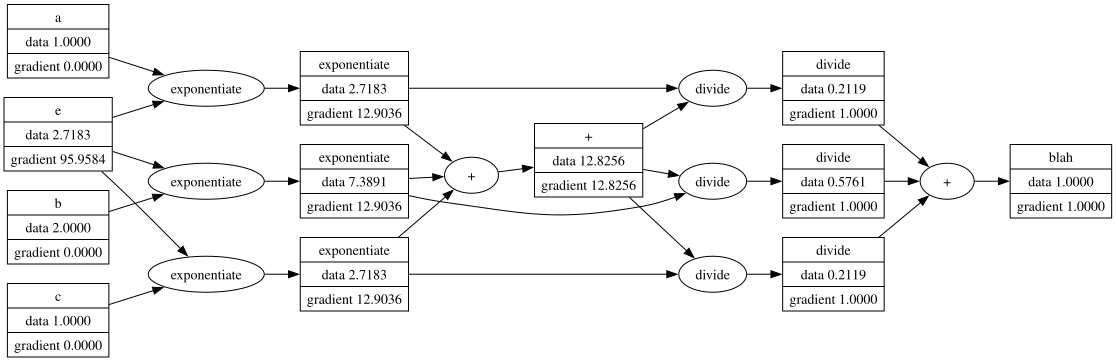

In [6]:
root.gradient = 1.0
root.backward()
draw(root)